# S&P 500 Equity + Option Analytics: Model-Based Features

Every feature in [`03_financial_features`](03_financial_features.ipynb) is a rule written in
advance: a window, a difference, a rank. The feature built here is not. It is the output of a
model whose parameters are **estimated from the data**, and that changes what has to be checked.
A rule cannot leak by being fitted, because there is nothing to fit. A fitted parameter can, and
the only thing that decides whether it did is which rows the estimation window contained.

The model is a **GJR-GARCH(1,1)**, an equation for how a share's variance evolves from one
session to the next. What it gives back is a **conditional volatility**: an estimate, made with
what was known at the close of one session, of how much the share will move over the next one.
That is a forward-looking quantity, and it is why this notebook exists. Stage 03's variance risk
premium subtracts a *backward*-looking realized volatility from the option market's implied
volatility, so it compares a forecast against a memory. Replacing the second half with a
forecast makes both halves forecasts.

## Learning objectives

- Estimate the parameters of a volatility model on one window of a share's returns, then run the
  model forward over later sessions without re-estimating it, so that no later session can move
  a parameter
- Write the estimation window and the window the model is run over as one table per fold, and
  assert that the first ends before the second begins rather than saying that it does
- Pin every quantity the recursion starts from - the scaling, the starting variance and the
  bounds it is clipped to - to the estimation window, because a library that recomputes them
  over whatever series it is handed will read later data through them
- Rebuild the option market's variance premium against a forecast rather than against a memory,
  and test whether the change moves what the premium says about future returns
- Test a difference between two dependent measurements directly, instead of inferring it from
  two tests that were each about something else

## Book reference, prerequisites and artifacts

Chapter 9, Section 9.3. Reads the daily share bars through `load_sp500_daily_bars()`, the
implied volatility level and the variance risk premium from
[`03_financial_features`](03_financial_features.ipynb)'s `features/financial.parquet`, and the
primary label from [`02_labels`](02_labels.ipynb). Writes
`features/model_based.parquet` with a `.digest.json` sidecar, read by every downstream model
notebook through `load_modeling_dataset`, and by [`05_evaluation`](05_evaluation.ipynb).
[`08_garch_volatility`](../../09_model_based_features/08_garch_volatility.ipynb) introduces the
model itself.

In [1]:
"""S&P 500 Equity + Option Analytics: Model-Based Features."""

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from arch import arch_model
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.utils.artifact_digest import read_digest, value_digest, write_artifact
from case_studies.utils.cv_window import modeling_fold_boundaries
from data import load_sp500_daily_bars
from utils.artifact_specs import load_setup_config, resolve_label_horizon
from utils.cv_splits import load_evaluation_config
from utils.paths import display_path, get_case_study_dir
from utils.style import ml4t_palette

`MIN_OBS` is the shortest estimation window a fit is attempted on. A GJR-GARCH has four
parameters and its likelihood is flat in the asymmetry term unless the window contains enough
down sessions to identify it, so a year of sessions is the floor below which the notebook
declines to fit rather than returning an unstable estimate. `MAX_SYMBOLS` caps the universe;
`None` runs all of it. Both are read below and neither is re-assigned outside this cell, so the
value a test injects is the value the notebook runs on.

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
MIN_OBS = 252
MAX_SYMBOLS = None
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
FEATURES_DIR = CASE_DIR / "features"
PANEL_KEY = ["timestamp", "symbol"]
FINANCIAL_PATH = FEATURES_DIR / "financial.parquet"
LABELS_DIR = CASE_DIR / "labels"

## Configuration

Three things are bound here and each decides something below: the label the section F diagnostic
scores against and how far ahead it resolves, the fold timeline the estimation windows come
from, and the date the holdout begins.

**The folds come from one route.** `modeling_fold_boundaries` derives them from the label file
itself, through the same generator every downstream model reads, so a fold id means the same
thing in this artifact as it does on the other side of the join. Nothing here rebuilds a
calendar or replays a stored fold array.

In [4]:
SETUP = load_setup_config(CASE_STUDY_ID)
PRIMARY_LABEL = SETUP["labels"]["primary"]
# The outcome horizon, not the fold buffer: `labels.buffer` is 10D here because the purge has to
# clear the longest variant, while this label resolves in 5 sessions. The horizon is what sets
# section F's HAC bandwidth, because it is what makes consecutive daily IC values overlap.
_horizon = resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
if not _horizon or not str(_horizon).endswith("D"):
    raise ValueError(f"Expected a daily label horizon for {PRIMARY_LABEL}, found {_horizon!r}")
LABEL_HORIZON = int(str(_horizon)[:-1])
LABEL_VARIANTS = [PRIMARY_LABEL, *SETUP["labels"].get("variants", [])]

canonical_splits = modeling_fold_boundaries(CASE_STUDY_ID, PRIMARY_LABEL)
if not canonical_splits:
    raise RuntimeError(f"Canonical {PRIMARY_LABEL} modeling folds are unavailable")
evaluation_config = load_evaluation_config(CASE_STUDY_ID)
HOLDOUT_START = str(evaluation_config["holdout_start"])[:10]
HOLDOUT_END = str(evaluation_config["holdout_end"])[:10]

print(
    f"{len(canonical_splits)} walk-forward folds come from the {PRIMARY_LABEL} label file, "
    "through the same generator the downstream models read."
)
print(
    f"That label resolves {LABEL_HORIZON} sessions after the decision, so consecutive daily "
    f"scores in section F share {LABEL_HORIZON - 1} sessions of outcome and the standard errors "
    "there are corrected for it."
)
print(
    f"A fit is attempted only where the estimation window holds at least {MIN_OBS} sessions of "
    "returns."
)
print(f"Everything from {HOLDOUT_START} to {HOLDOUT_END} is the holdout.")

2 walk-forward folds come from the fwd_ret_5d label file, through the same generator the downstream models read.
That label resolves 5 sessions after the decision, so consecutive daily scores in section F share 4 sessions of outcome and the standard errors there are corrected for it.
A fit is attempted only where the estimation window holds at least 252 sessions of returns.
Everything from 2021-01-01 to 2021-12-31 is the holdout.


## A. Why a fitted feature is different

A feature from stage 03 is a function of past prices. Ask for the 20-session realized volatility
at some date and the answer depends on twenty numbers and nothing else; run the calculation on a
longer history and the value at that date does not move.

A model-based feature is a function of *parameters estimated from* prices, and the parameters
depend on every row in the estimation window. So the estimation window is part of the feature's
information set, in a way that no window in stage 03 was. If the window used to estimate the
parameters reaches past the date the feature is stamped with, then the feature at that date was
computed with knowledge of what happened afterwards - and it will look far better than it can
be, because the model was told the answer.

The discipline that removes it has three parts, and section B, section C and section E carry one
each: fix the estimation window before any model runs, estimate inside it and never re-estimate
outside it, and emit the fold the parameters came from alongside every value so a consumer can
only join what belongs together.

There is one more subtlety, and it is the one a careless implementation leaves in place. Fixing
the *parameters* is not enough. A recursion also needs a value to start from and a range to stay
inside, and a library asked to run a recursion will derive both from whatever series it is
handed. Section C measures what that costs here.

## B. The fold contract

Each row of the table below is one estimation window and the span the estimated model is then
run over. The parameters come from the left-hand span and nothing else; the model is then run
forward over both spans, which is what gives a downstream model a value for its own training
rows as well as its validation rows.

**A third fold is added for the holdout, and it is a deliberate choice rather than an
oversight.** A downstream stage that scores the holdout needs this feature defined over holdout
dates, so a fold whose estimation window ends before the holdout begins is added and its
inference span covers the holdout. That is safe for the reason this stage's whole method rests
on: the model reads prices, not labels, so a parameter estimated wholly before the boundary
cannot carry anything from beyond it. The estimation span is the one `evaluation.train_size`
declares for every other fold, not a second number kept here.

**The folds are the primary label's.** This case study configures five labels whose purge
buffers differ, so their folds are not identical, and building the feature five times over
would be five times the fitting for windows that differ by days. The assertion below is what
makes one set of folds sound: it checks that each estimation window used here ends strictly
before the corresponding validation span begins **for every configured label**, so whichever
label a downstream model is trained on, no parameter it receives was estimated on a session
inside its own validation window.

In [5]:
splits = [
    {
        "fold": s["fold"],
        "fit_start": str(s["train_start"]),
        "fit_end": str(s["train_end"]),
        "infer_start": str(s["val_start"]),
        "infer_end": str(s["val_end"]),
        "is_holdout": False,
    }
    for s in canonical_splits
]

_train_size = str(evaluation_config["train_size"])
if not _train_size.endswith("Y"):
    raise ValueError(f"Expected an annual evaluation.train_size, found {_train_size!r}")
_train_years = int(_train_size[:-1])
splits.append(
    {
        "fold": len(splits),
        "fit_start": f"{int(HOLDOUT_START[:4]) - _train_years}-01-01",
        "fit_end": f"{int(HOLDOUT_START[:4]) - 1}-12-31",
        "infer_start": HOLDOUT_START,
        "infer_end": HOLDOUT_END,
        "is_holdout": True,
    }
)
# The fold ids run newest window first, which is what the generator assigns and what every
# downstream join expects. The table and the figure below are ordered oldest first so the reader
# sees the walk forward in the direction time runs.
CHRONOLOGICAL = sorted(splits, key=lambda row: row["fit_start"])
pl.DataFrame(CHRONOLOGICAL)

fold,fit_start,fit_end,infer_start,infer_end,is_holdout
i64,str,str,str,str,bool
1,"""2017-01-05""","""2018-12-19""","""2019-01-07""","""2020-01-03""",false
0,"""2018-01-04""","""2019-12-18""","""2020-01-06""","""2020-12-23""",false
2,"""2019-01-01""","""2020-12-31""","""2021-01-01""","""2021-12-31""",true


The three assertions below are the fold contract, executed. The first is the seal: no
estimation window may reach into the holdout. The second is the ordering every fold depends on:
the parameters are estimated strictly before the span they are run over. The third is what makes
the primary label's folds usable for the other four.

In [6]:
for row in splits:
    assert row["fit_end"] < HOLDOUT_START, f"fold {row['fold']} estimates on holdout sessions"
    assert row["fit_end"] < row["infer_start"], f"fold {row['fold']} infers before it estimates"

development_splits = [row for row in splits if not row["is_holdout"]]
for label in LABEL_VARIANTS:
    label_splits = modeling_fold_boundaries(CASE_STUDY_ID, label)
    assert label_splits and len(label_splits) == len(development_splits), (
        f"{label} resolves {len(label_splits or [])} folds against {len(development_splits)} here"
    )
    for row, own in zip(development_splits, label_splits, strict=True):
        assert row["fit_end"] < str(own["val_start"]), (
            f"fold {row['fold']}'s estimation window reaches into {label}'s validation span"
        )
print(
    f"Each of the {len(development_splits)} development folds estimates entirely before the "
    f"validation span begins, for all {len(LABEL_VARIANTS)} configured labels."
)
print(f"All {len(splits)} folds, the holdout one included, estimate before {HOLDOUT_START}.")

Each of the 2 development folds estimates entirely before the validation span begins, for all 5 configured labels.
All 3 folds, the holdout one included, estimate before 2021-01-01.


### F1. The fold contract

What the table states, the figure shows: every estimation bar sits entirely to the left of the
inference bar it feeds, and every estimation bar ends left of the holdout rule. The last row is
the added holdout fold, and it is the one to read carefully - its inference bar is the only one
that crosses the rule, and its estimation bar stops short of it.

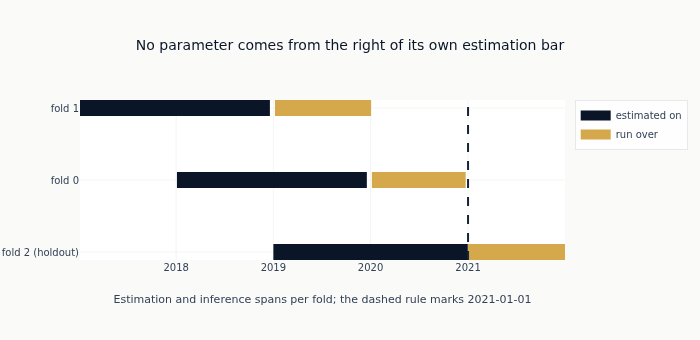

In [7]:
fit_colour, infer_colour = ml4t_palette(2, categorical=True)
fig = go.Figure()
for row_index, row in enumerate(CHRONOLOGICAL):
    label = f"fold {row['fold']}" + (" (holdout)" if row["is_holdout"] else "")
    for span, colour, name in (
        (("fit_start", "fit_end"), fit_colour, "estimated on"),
        (("infer_start", "infer_end"), infer_colour, "run over"),
    ):
        fig.add_trace(
            go.Scatter(
                x=[row[span[0]], row[span[1]]],
                y=[label, label],
                mode="lines",
                line=dict(color=colour, width=16),
                name=name,
                showlegend=row_index == 0,
            )
        )
fig.add_vline(x=HOLDOUT_START, line_dash="dash", line_color=ml4t_palette(3)[2])
fig.update_layout(
    title="No parameter comes from the right of its own estimation bar",
    xaxis_title=f"Estimation and inference spans per fold; the dashed rule marks {HOLDOUT_START}",
    height=340,
)
fig.update_yaxes(autorange="reversed")
fig.show()

## C. The conditional volatility model

GJR-GARCH(1,1) says next session's variance is a weighted sum of three things: a constant, how
large the last session's move was, and what the variance already was.

$$\sigma^2_t = \omega + (\alpha + \gamma \mathbb{1}_{r_{t-1}<0}) r^2_{t-1} + \beta \sigma^2_{t-1}$$

The $\gamma$ term is what the GJR variant adds to a plain GARCH: it lets a *negative* return
raise the variance by more than a positive return of the same size. That asymmetry is well
documented for equities and it is the reason the variant is worth the extra parameter here
(Glosten, Jagannathan and Runkle, 1993). $\alpha + \gamma/2 + \beta$ is the model's
**persistence** - how much of today's variance is still present tomorrow - and section D shows
what it comes out at.

Returns are multiplied by a hundred before fitting. The optimizer works on the variance of the
series it is handed, and a daily equity return is a fraction of a percent whose square is four
orders of magnitude smaller again; on that scale $\omega$ is small enough that the likelihood is
flat in it to the optimizer's tolerance. Working in percent puts every parameter within a couple
of orders of magnitude of one.

### C.1 Fit on the estimation window, then run forward without re-estimating

The returns are taken on the **adjusted** close, `close` multiplied by `adj_factor`, for the
reason `03_financial_features` gives at length: a four-for-one split reads as a three-quarter
loss on the printed close, and a single such session is a squared return four orders of
magnitude above anything else in the window. It would move $\omega$, it would be scored as an
enormous surprise by the third feature below, and neither would be about the share.

**Fixing the parameters is not enough on its own, and this is where a convenience method costs
a value.** `arch`'s `fix` runs the recursion with parameters you supply, but it derives two
other quantities from the series it is handed: the value the recursion starts from, and a pair
of bounds every variance is clipped to. Handed the estimation window and the inference span
together, it derives both from all of it - so a variance at a date inside the estimation window
depends on returns that came after it, through the clipping range.

So the recursion below is explicit, and the three things it needs beyond the parameters - the
scaling, the starting variance and the bounds - are all derived from the estimation window
alone, using `arch`'s own functions for each. The recursion itself reads only $r_{t-1}$ and
$\sigma^2_{t-1}$, so once it has started it never reads forward.

**What that does and does not make point-in-time is worth being exact about, because the two
halves of the emitted span are not the same kind of quantity.** A value on the inference span
was produced by parameters, a starting variance and bounds that all come from sessions strictly
before it, so it is a quantity that could have been computed on the day it is stamped with. A
value on the estimation window was not: the parameters were estimated from that whole window,
and the starting variance is an average over its first sessions, so an early estimation-window
value is a retrospective transform rather than a live one. Those values are emitted because a
downstream model needs a feature on its own training rows, and they carry the fold id that says
which window produced them. They are not evidence about what the model could have known.

C.2 measures what the convenience would have cost, rather than asserting that it costs
something, because a clipping range twelve orders of magnitude wide might never bind.

In [8]:
def training_filter_state(result, train_returns: pd.Series) -> tuple[float, float, tuple]:
    """Scaling, starting variance and clipping bounds, from the estimation window alone."""
    scale = float(result.model.scale)
    mu = float(result.params.get("mu", result.params.get("Const", 0.0)))
    residuals = train_returns.to_numpy(dtype=float) * scale - mu
    backcast = float(result.model.volatility.backcast(residuals))
    bounds = result.model.volatility.variance_bounds(residuals)
    return scale, backcast, (float(bounds[:, 0].min()), float(bounds[:, 1].max()))


def causal_gjr_filter(
    returns: pd.Series, params: pd.Series, scale: float, backcast: float, bounds: tuple
) -> pd.Series:
    """Run the fixed GJR-GARCH recursion forward, reading only earlier rows."""
    mu = float(params.get("mu", params.get("Const", 0.0)))
    omega, alpha = float(params["omega"]), float(params["alpha[1]"])
    gamma, beta = float(params["gamma[1]"]), float(params["beta[1]"])
    low, high = bounds

    residuals = returns.to_numpy(dtype=float) * scale - mu
    variance = np.empty(len(residuals), dtype=float)
    variance[0] = np.clip(omega + (alpha + 0.5 * gamma + beta) * backcast, low, high)
    for t in range(1, len(residuals)):
        shock = residuals[t - 1] ** 2
        variance[t] = np.clip(
            omega + alpha * shock + gamma * shock * (residuals[t - 1] < 0) + beta * variance[t - 1],
            low,
            high,
        )
    return pd.Series(np.sqrt(variance) / scale, index=returns.index)

One function per security and fold: estimate on the sessions inside the estimation window, then
run the recursion over the estimation window and the inference span together. It returns the
filtered path and the estimated parameters, so section D reads the parameters this loop already
produced rather than estimating a second set of its own.

In [9]:
ANNUALIZE = SETUP["evaluation"]["periods_per_year"] ** 0.5


def fit_and_filter(returns: pd.Series, row: dict) -> tuple[pd.Series, dict] | None:
    """Estimate on one fold's window, then filter the window and the span it feeds."""
    fit_slice = returns[
        (returns.index >= pd.Timestamp(row["fit_start"]))
        & (returns.index <= pd.Timestamp(row["fit_end"]))
    ]
    if len(fit_slice) < MIN_OBS:
        return None
    run_slice = returns[
        (returns.index >= pd.Timestamp(row["fit_start"]))
        & (returns.index <= pd.Timestamp(row["infer_end"]))
    ]
    if run_slice.empty:
        return None
    try:
        result = arch_model(
            fit_slice, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="Normal"
        ).fit(disp="off", show_warning=False)
        scale, backcast, bounds = training_filter_state(result, fit_slice)
        filtered = causal_gjr_filter(run_slice, result.params, scale, backcast, bounds)
    except Exception:
        return None

    alpha = float(result.params.get("alpha[1]", 0.0))
    gamma = float(result.params.get("gamma[1]", 0.0))
    beta = float(result.params.get("beta[1]", 0.0))
    return filtered * ANNUALIZE / 100.0, {
        "alpha": alpha,
        "gamma": gamma,
        "beta": beta,
        "persistence": alpha + gamma / 2 + beta,
    }

The securities and their returns. A row is emitted for a security in a given fold when the
estimation window holds enough sessions and the optimizer returns; the count of those is
reported below, because a security missing from one fold's rows is a security a downstream
model has no conditional volatility for on those dates, and that is worth knowing before it
turns up as a gap.

In [10]:
bars = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE).sort(["symbol", "timestamp"])
bars = bars.with_columns((pl.col("close") * pl.col("adj_factor")).alias("adj_close"))
symbols = bars["symbol"].unique().sort().to_list()
if MAX_SYMBOLS is not None:
    symbols = symbols[:MAX_SYMBOLS]
    print(f"Reduced run: {MAX_SYMBOLS} of {bars['symbol'].n_unique()} securities")

log_returns: dict[str, pd.Series] = {}
for key, frame in (
    bars.select(["symbol", "timestamp", "adj_close"])
    .filter(pl.col("symbol").is_in(symbols))
    .partition_by("symbol", as_dict=True, maintain_order=True)
    .items()
):
    series = (
        frame.sort("timestamp")
        .with_columns((pl.col("adj_close").log().diff() * 100).alias("ret_pct"))
        .drop_nulls("ret_pct")
        .select(["timestamp", "ret_pct"])
        .to_pandas()
        .set_index("timestamp")["ret_pct"]
    )
    if not series.empty:
        log_returns[key[0]] = series

print(f"{len(log_returns)} securities, {bars['timestamp'].min()} to {bars['timestamp'].max()}")

638 securities, 2017-01-03 to 2021-12-31


### C.2 What the convenience method would have cost

The claim above is that handing `fix` the estimation window and the inference span together lets
later returns reach an earlier date through the clipping range. The range is wide - the bounds
sit six orders of magnitude either side of a local variance estimate - so it is entirely
possible that it never binds and the whole concern is theoretical. That is a measurement, not an
argument, so it is measured.

The test isolates the clipping range from everything else. For a sample of securities on the
first fold, `fix` is called twice with the same estimated parameters: once on the estimation
window alone, once on the estimation window followed by the inference span. Both series start at
the same session, so the starting variance - which `arch` reads from the first sessions only -
is identical between them. The clipping range is then the one thing that differs, and any
difference on the sessions the two calls share is what it did.

In [11]:
BOUNDS_SAMPLE = 40
first_split = splits[0]
bounds_effect = []
for symbol in symbols[:BOUNDS_SAMPLE]:
    returns = log_returns.get(symbol)
    if returns is None:
        continue
    fit_slice = returns[
        (returns.index >= pd.Timestamp(first_split["fit_start"]))
        & (returns.index <= pd.Timestamp(first_split["fit_end"]))
    ]
    run_slice = returns[
        (returns.index >= pd.Timestamp(first_split["fit_start"]))
        & (returns.index <= pd.Timestamp(first_split["infer_end"]))
    ]
    if len(fit_slice) < MIN_OBS:
        continue
    try:
        params = (
            arch_model(fit_slice, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="Normal")
            .fit(disp="off", show_warning=False)
            .params
        )
        short = arch_model(
            fit_slice, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="Normal"
        ).fix(params)
        long_ = arch_model(
            run_slice, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="Normal"
        ).fix(params)
    except Exception:
        continue
    shared = np.asarray(short.conditional_volatility, dtype=float)
    overlap = np.asarray(long_.conditional_volatility, dtype=float)[: len(shared)]
    bounds_effect.append(float(np.nanmax(np.abs(shared - overlap)) / np.nanmax(shared)))

if bounds_effect:
    print(f"{len(bounds_effect)} securities compared on fold {first_split['fold']}")
    print(
        "largest change in the reported volatility on a shared session, as a share of that "
        f"security's own largest value: {max(bounds_effect):.1%}"
    )
else:
    print("No security in the sample had an estimation window long enough to compare.")

38 securities compared on fold 0
largest change in the reported volatility on a shared session, as a share of that security's own largest value: 0.9%


The clipping range does bind. Across the **38** securities in the sample with a long enough
estimation window, extending the series handed to `fix` moves the volatility it reports on an
estimation-window session by up to **0.9%** of that security's own largest value. That is small,
and it is not zero, and what it is is a training-period value that depends on validation-period
returns - in a stage whose whole subject is which rows a quantity was allowed to see. Hence the
explicit recursion above.

In [12]:
filtered_parts: list[pl.DataFrame] = []
parameter_rows: list[dict] = []
attempted = fitted = 0

for row in splits:
    for symbol in symbols:
        returns = log_returns.get(symbol)
        if returns is None or returns.empty:
            continue
        attempted += 1
        outcome = fit_and_filter(returns, row)
        if outcome is None:
            continue
        fitted += 1
        path, params = outcome
        filtered_parts.append(
            pl.DataFrame({"timestamp": path.index.values, "garch_cond_vol": path.to_numpy()})
            .with_columns(pl.col("timestamp").cast(pl.Date))
            .with_columns(pl.lit(symbol).alias("symbol"), pl.lit(row["fold"]).alias("fold"))
        )
        parameter_rows.append({"symbol": symbol, "fold": row["fold"], **params})
    print(f"  fold {row['fold']}: {len(parameter_rows)} cumulative fits")

garch = pl.concat(filtered_parts).sort(["symbol", "timestamp"])
parameters = pl.DataFrame(parameter_rows)
print(f"{fitted:,} of {attempted:,} security-folds produced a fit ({fitted / attempted:.1%})")
print(f"{garch.height:,} filtered values over {garch['symbol'].n_unique()} securities")

  fold 0: 502 cumulative fits


  fold 1: 1005 cumulative fits


  fold 2: 1510 cumulative fits
1,510 of 1,914 security-folds produced a fit (78.9%)
1,091,740 filtered values over 562 securities


## D. Fit stability across folds

The whole method rests on re-estimating at every fold boundary, and that is only worth its cost
if the estimates actually move. If the same parameters come back fold after fold, the refit
bought nothing and one estimation would have done. If they swing, then the feature carries
whatever the estimation window happened to contain as much as it carries anything about the
share, and a reader should treat it accordingly - and a consumer must join on the fold, because
the same date and security carry a different value depending on which window produced it.

Persistence is the summary to read, and it is the sum of the other three: $\alpha + \gamma/2 +
\beta$. A value near one means a shock to volatility decays slowly, so today's variance says
something about tomorrow's - which is the property that makes a conditional volatility worth
forecasting at all. A value near zero would mean the model has nothing to carry forward and the
forecast is close to a constant.

### F3. Fit stability across folds

One line per estimated parameter, the windows in the order they run. The point is drawn at the
median across securities and the bar spans the middle half of them, so a line that stays flat
says the securities as a group were estimated the same way in every window and a line that moves
says they were not. All four parameters are dimensionless and bounded the same way, so they
share an axis. Persistence is not one of the four inputs to the model; it is the sum of the
other three and is drawn beside them because it is the quantity that says how long a shock
lasts.

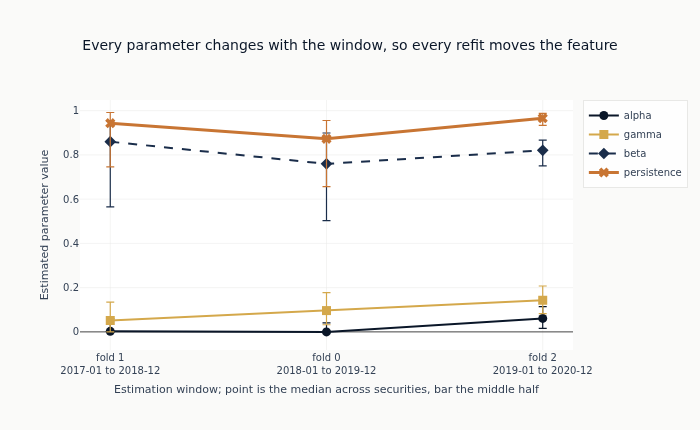

In [13]:
ordered_folds = sorted(splits, key=lambda row: row["fit_start"])
axis_labels = [
    f"fold {row['fold']}<br>{row['fit_start'][:7]} to {row['fit_end'][:7]}" for row in ordered_folds
]
# Two of the four palette colours are near-identical navies, so each line also carries its own
# dash pattern and marker; the chart stays readable where the colours do not separate.
parameter_colours = ml4t_palette(4, categorical=True)
styles = [
    ("alpha", parameter_colours[0], "solid", "circle", 2),
    ("gamma", parameter_colours[1], "solid", "square", 2),
    ("beta", parameter_colours[2], "dash", "diamond", 2),
    ("persistence", parameter_colours[3], "solid", "x", 3),
]
fig = go.Figure()
for name, colour, dash, marker, width in styles:
    medians, lower, upper = [], [], []
    for row in ordered_folds:
        column = parameters.filter(pl.col("fold") == row["fold"])[name]
        medians.append(column.median())
        lower.append(column.median() - column.quantile(0.25))
        upper.append(column.quantile(0.75) - column.median())
    fig.add_scatter(
        x=axis_labels,
        y=medians,
        error_y=dict(type="data", symmetric=False, array=upper, arrayminus=lower, thickness=1.2),
        mode="lines+markers",
        name=name,
        line=dict(color=colour, width=width, dash=dash),
        marker=dict(size=9, symbol=marker),
    )
fig.update_layout(
    title="Every parameter changes with the window, so every refit moves the feature",
    xaxis_title="Estimation window; point is the median across securities, bar the middle half",
    yaxis_title="Estimated parameter value",
    height=430,
)
fig.show()

In [14]:
stability = (
    parameters.group_by("fold")
    .agg(
        pl.len().alias("securities"),
        pl.col("alpha").median().round(4).alias("median alpha"),
        pl.col("gamma").median().round(4).alias("median gamma"),
        pl.col("beta").median().round(4).alias("median beta"),
        pl.col("persistence").median().round(4).alias("median persistence"),
    )
    .join(
        pl.DataFrame(
            {
                "fold": [row["fold"] for row in ordered_folds],
                "estimated over": [
                    f"{row['fit_start']} to {row['fit_end']}" for row in ordered_folds
                ],
            }
        ),
        on="fold",
    )
    .sort("estimated over")
    .select(
        ["fold", "estimated over", "securities"]
        + [c for c in ["median alpha", "median gamma", "median beta", "median persistence"]]
    )
)
stability

fold,estimated over,securities,median alpha,median gamma,median beta,median persistence
i64,str,u32,f64,f64,f64,f64
1,"""2017-01-05 to 2018-12-19""",503,0.0023,0.0515,0.8595,0.9433
0,"""2018-01-04 to 2019-12-18""",502,0.0,0.0962,0.7594,0.8727
2,"""2019-01-01 to 2020-12-31""",505,0.0609,0.1429,0.8206,0.9658


The parameters move, and they move enough that re-estimating at each boundary is doing real
work. Median persistence runs **0.943**, **0.873** and **0.966** across the three windows in the
order they run - a spread of **0.09** between windows that overlap by a year, and the highest
value on the window containing 2020. Its parts move more than the sum does: median $\alpha$ goes
**0.002**, **0.000**, **0.061** and median $\gamma$ **0.052**, **0.096**, **0.143**, so on the
earlier windows almost the whole response to a shock is carried by the asymmetric term and only
a *down* session raises the estimated variance, while on the window containing 2020 the
symmetric term takes a share of it too. A downstream model reading this feature is reading a
quantity whose generating parameters were re-estimated, not a fixed transform, and the size of
that movement is the reason the fold id has to travel with the value.

### F2. What the model inferred, over the sessions it was run over

The feature itself, drawn against the quantity it is meant to improve on. The line is the median
across securities of the conditional volatility the model reports, and beside it the median of
stage 03's 20-session realized volatility on the same dates. Two restrictions apply and both
matter. Only the **inference** spans are drawn, because the estimation windows are the sessions
the parameters came from and the reader is owed a picture of the feature where it is out of
sample. And only the **development** folds are drawn: the holdout fold's values are in the
artifact because a later stage needs them, and a figure read during development does not get to
look at them.

What to look for is not that the two agree - they are different quantities, one an estimate of
the next session and the other an average over the last twenty - but *when* they part company.
A conditional volatility responds to a shock the session after it, while a twenty-session
average takes a month to absorb it and another month to forget it.

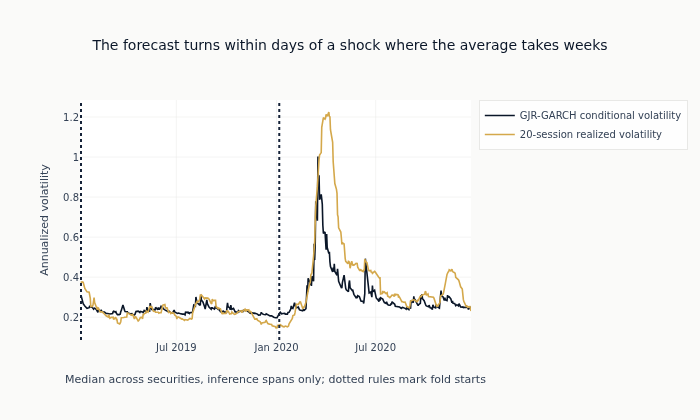

In [15]:
financial = pl.read_parquet(FINANCIAL_PATH).select(
    [*PANEL_KEY, "iv_30_atm", "rv_20", "ivrv_spread"]
)
DEVELOPMENT_FOLDS = [row["fold"] for row in splits if not row["is_holdout"]]
inference_only = pl.concat(
    [
        garch.filter(
            (pl.col("fold") == row["fold"])
            & (pl.col("timestamp") >= pl.lit(row["infer_start"]).str.to_date())
            & (pl.col("timestamp") <= pl.lit(row["infer_end"]).str.to_date())
        )
        for row in splits
        if not row["is_holdout"]
    ]
).sort(PANEL_KEY)

daily_medians = (
    inference_only.join(financial, on=PANEL_KEY, how="left")
    .group_by("timestamp")
    .agg(
        pl.col("garch_cond_vol").median().alias("conditional"),
        pl.col("rv_20").median().alias("realized"),
    )
    .sort("timestamp")
)

series_colours = ml4t_palette(2, categorical=True)
fig = go.Figure()
for column, name, colour in (
    ("conditional", "GJR-GARCH conditional volatility", series_colours[0]),
    ("realized", "20-session realized volatility", series_colours[1]),
):
    fig.add_scatter(
        x=daily_medians["timestamp"].to_list(),
        y=daily_medians[column].to_list(),
        mode="lines",
        name=name,
        line=dict(color=colour, width=1.6),
    )
for row in splits:
    if not row["is_holdout"]:
        fig.add_vline(x=row["infer_start"], line_dash="dot", line_color=ml4t_palette(3)[2])
fig.update_layout(
    title="The forecast turns within days of a shock where the average takes weeks",
    xaxis_title="Median across securities, inference spans only; dotted rules mark fold starts",
    yaxis_title="Annualized volatility",
    height=420,
)
fig.show()

## E. Combine and emit

Three columns go out, and the second is the one this notebook was written for.

- `garch_cond_vol` - the conditional volatility itself, annualized.
- `garch_ivrv_spread` - the implied volatility of the coming month less that forecast. Stage 03's
  `ivrv_spread` subtracts a *realized* volatility from the same implied level, so the two differ
  in the denominator alone and in nothing else.
- `garch_vol_surprise` - the size of the session's actual move divided by the volatility that
  had been forecast for it. The denominator is a standard deviation, and most sessions move less
  than one, so a well-calibrated forecast puts the typical value below one rather than at it;
  what the column is for is the tail, where a value of three or four says the session moved far
  more than the model had any reason to expect.

The return in `garch_vol_surprise` is the same adjusted log return the model was estimated on,
annualized to the same units as the denominator so the ratio is a comparison of like with like.

In [16]:
returns_panel = (
    bars.select(["symbol", "timestamp", "adj_close"])
    .sort(["symbol", "timestamp"])
    .with_columns((pl.col("adj_close").log().diff().over("symbol") * ANNUALIZE).alias("_ann_ret"))
    .select([*PANEL_KEY, "_ann_ret"])
)

model_based = (
    garch.join(returns_panel, on=PANEL_KEY, how="left")
    .join(financial.select([*PANEL_KEY, "iv_30_atm"]), on=PANEL_KEY, how="left")
    .with_columns(
        (pl.col("_ann_ret").abs() / pl.col("garch_cond_vol")).alias("garch_vol_surprise"),
        (pl.col("iv_30_atm") - pl.col("garch_cond_vol")).alias("garch_ivrv_spread"),
    )
    .drop(["_ann_ret", "iv_30_atm"])
    .select([*PANEL_KEY, "fold", "garch_cond_vol", "garch_ivrv_spread", "garch_vol_surprise"])
    .sort(["fold", *PANEL_KEY])
)
FEATURE_COLS = ["garch_cond_vol", "garch_ivrv_spread", "garch_vol_surprise"]
assert model_based.select(["fold", *PANEL_KEY]).is_duplicated().sum() == 0, "duplicate panel key"
assert set(model_based["fold"].unique()) == {row["fold"] for row in splits}, "fold ids disagree"

### E.1 What each column covers, fold by fold

The panel key is `timestamp` + `symbol` **and** `fold`, because the same date and security
appear once per fold with a different value each time - that is what per-fold estimation
means, and it is why a consumer has to join on all three. The coverage below is reported per
fold rather than pooled. The holdout fold is in this artifact because a later stage needs the
feature defined there, so its rows are counted here and read no further: the distribution
columns below are taken over the development folds alone, which keeps every number printed
during development to sessions development is allowed to see.

In [17]:
coverage = (
    model_based.group_by("fold")
    .agg(
        pl.len().alias("rows"),
        *[(pl.col(c).is_not_null().mean() * 100).round(1).alias(f"{c} %") for c in FEATURE_COLS],
    )
    .sort("fold")
)
coverage

fold,rows,garch_cond_vol %,garch_ivrv_spread %,garch_vol_surprise %
i32,u32,f64,f64,f64
0,361006,100.0,78.4,100.0
1,363138,100.0,75.6,100.0
2,367596,100.0,77.8,100.0


In [18]:
development = model_based.filter(pl.col("fold").is_in(DEVELOPMENT_FOLDS))
pl.DataFrame(
    {
        "feature": FEATURE_COLS,
        "median": [development[c].median() for c in FEATURE_COLS],
        "std": [development[c].std() for c in FEATURE_COLS],
        "1st pct": [development[c].quantile(0.01) for c in FEATURE_COLS],
        "99th pct": [development[c].quantile(0.99) for c in FEATURE_COLS],
    }
)

feature,median,std,1st pct,99th pct
str,f64,f64,f64,f64
"""garch_cond_vol""",0.240281,0.147005,0.119034,0.802399
"""garch_ivrv_spread""",0.004219,0.115179,-0.270797,0.314544
"""garch_vol_surprise""",0.565028,0.785388,0.009385,3.569992


### E.2 Write the artifact

The parquet goes out with a digest sidecar beside it, the same way stage 03 writes its matrix: a
small JSON file recording a hash of the values, the row count, the key columns, and a hash of
everything the values were built from. The hash is over the content rather than the file's
bytes, so a re-write in a different row order leaves it alone and any changed value moves it.
What that buys is provenance a file name cannot give: a model trained on these values records
the hash, and a later run can tell whether the feature it is reading is the feature it trained
on. The two inputs recorded here are the share bars the model was estimated on and stage 03's
matrix, which supplied the implied volatility the second feature subtracts from.

In [19]:
record = write_artifact(
    model_based,
    FEATURES_DIR / "model_based.parquet",
    keys=["fold", *PANEL_KEY],
    written_by=f"case_studies/{CASE_STUDY_ID}/04_model_based_features.py",
    inputs={
        "load_sp500_daily_bars": value_digest(bars.select([*PANEL_KEY, "close", "adj_factor"])),
        "features/financial.parquet": read_digest(FINANCIAL_PATH)["digest"],
    },
)
print(f"Wrote {display_path(FEATURES_DIR / 'model_based.parquet')}, digest {record['digest']}")
print(f"{record['n_rows']:,} rows on {record['keys']}, read through load_modeling_dataset")

Wrote case_studies/sp500_equity_option_analytics/features/model_based.parquet, digest 9e3932b70d400777
1,091,740 rows on ['fold', 'timestamp', 'symbol'], read through load_modeling_dataset


## F. Incremental evaluation

One question, asked on validation rows only: does the option market's variance premium say
something different about future returns when its denominator is a forecast instead of a memory?

The measure is the **information coefficient**: on each decision date, the rank correlation
across securities between the feature and the return that follows. That gives one number per
date; the average over dates is the feature's IC, and its standard error has to account for
consecutive dates sharing outcome sessions, which is what the label horizon bound above is for.

**This section selects nothing.** All three features were written to the artifact in E.2 before
it ran, and the holdout fold is excluded from every number below. `05_evaluation` is where
features are screened, and it runs that screen fold by fold over the whole matrix.

In [20]:
label = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet").rename(
    {PRIMARY_LABEL: "forward_return"}
)
scored = (
    model_based.join(
        inference_only.select([*PANEL_KEY, "fold"]), on=[*PANEL_KEY, "fold"], how="semi"
    )
    .join(label.select([*PANEL_KEY, "forward_return"]), on=PANEL_KEY, how="inner")
    .sort(PANEL_KEY)
)
assert scored.filter(pl.col("timestamp") >= pl.lit(HOLDOUT_START).str.to_date()).is_empty(), (
    "the validation scoring frame reaches into the holdout"
)
assert set(scored["fold"].unique()) <= set(DEVELOPMENT_FOLDS), "a holdout fold reached section F"
print(f"{scored.height:,} scored rows over {scored['timestamp'].n_unique():,} decision dates")

230,716 scored rows over 497 decision dates


In [21]:
MIN_CROSS_SECTION = 10


def ic_series(frame: pl.DataFrame, column: str) -> pl.DataFrame:
    """Per-date cross-sectional rank correlation of *column* against the forward return.

    A date with fewer than ``MIN_CROSS_SECTION`` securities comes back as a null rather
    than as a correlation over three names, and is dropped here rather than averaged in.
    """
    scored_frame = frame.select([*PANEL_KEY, column, "forward_return"]).drop_nulls()
    scored_frame = scored_frame.rename({column: "prediction"})
    series = cross_sectional_ic_series(
        scored_frame,
        scored_frame,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    )
    return series.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan()).sort("timestamp")


ic_rows = []
for column in FEATURE_COLS:
    series = ic_series(scored, column)
    if len(series) <= MIN_CROSS_SECTION:
        print(
            f"{column}: only {len(series)} dates carry a cross-section of at least "
            f"{MIN_CROSS_SECTION} securities, so no IC is reported for it"
        )
        continue
    stats = compute_ic_hac_stats(series, label_horizon=LABEL_HORIZON)
    ic_rows.append(
        {
            "feature": column,
            "ic": stats["mean_ic"],
            "hac_t": stats["t_stat"],
            "p": stats["p_value"],
            "dates": len(series),
        }
    )

if ic_rows:
    fdr = benjamini_hochberg_fdr([r["p"] for r in ic_rows], alpha=0.05, return_details=True)
    for row, survives in zip(ic_rows, fdr["rejected"], strict=True):
        row["survives FDR"] = bool(survives)
    ic_table = pl.DataFrame(ic_rows).with_columns(
        pl.col("ic").round(4), pl.col("hac_t").round(2), pl.col("p").round(4)
    )
else:
    ic_table = pl.DataFrame(schema={"feature": pl.Utf8, "ic": pl.Float64})
ic_table

feature,ic,hac_t,p,dates,survives FDR
str,f64,f64,f64,i64,bool
"""garch_cond_vol""",-0.0065,-0.34,0.7334,497,false
"""garch_ivrv_spread""",-0.0029,-0.34,0.7336,497,false
"""garch_vol_surprise""",0.0027,0.48,0.6348,497,false


### F4. Incremental IC by feature

Each bar is one feature's mean IC with its HAC t-statistic printed past the bar end. A
t-statistic of about two is the conventional threshold for calling a mean distinguishable from
zero at all; the Benjamini-Hochberg correction applied above lowers the bar each individual
feature has to clear, because three tests give three chances to find something by accident. A
bar is drawn in the darker colour where its feature clears that corrected threshold, so a chart
in which every bar is the lighter colour is one in which none of them did.

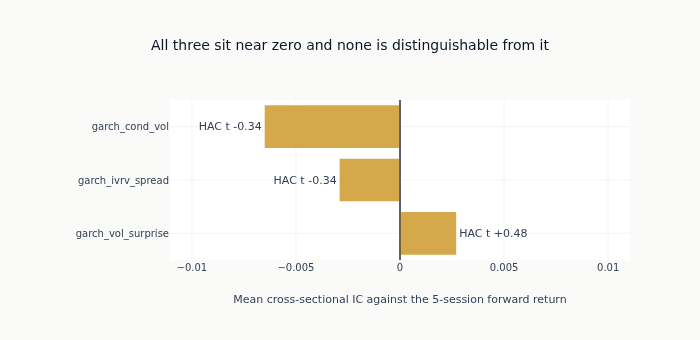

In [22]:
if ic_table.is_empty():
    print("No IC series survived the cross-section floor, so there is nothing to draw here.")
else:
    bar_colour, faded = ml4t_palette(2, categorical=True)
    ordered = ic_table.sort(pl.col("ic").abs(), descending=True)
    fig = go.Figure()
    fig.add_bar(
        x=ordered["ic"].to_list(),
        y=ordered["feature"].to_list(),
        orientation="h",
        marker_color=[bar_colour if s else faded for s in ordered["survives FDR"].to_list()],
        text=[f"HAC t {t:+.2f}" for t in ordered["hac_t"].to_list()],
        textposition="outside",
        cliponaxis=False,
    )
    fig.add_vline(x=0.0, line_width=1, line_color=ml4t_palette(3)[2])
    _span = max(abs(v) for v in ordered["ic"].to_list()) * 1.7
    fig.update_layout(
        title="All three sit near zero and none is distinguishable from it",
        xaxis_title=(f"Mean cross-sectional IC against the {LABEL_HORIZON}-session forward return"),
        xaxis=dict(range=[-_span, _span]),
        yaxis=dict(autorange="reversed"),
        margin=dict(l=170, r=70),
        height=340,
    )
    fig.show()

### F5. The forecast denominator against the memory denominator

The comparison the notebook was written to make. Both variants are scored on the rows where both
are defined, so the only thing that differs between the first two bars is the denominator: the
forecast in one, the trailing average in the other. Scoring stage 03's spread over its own wider
panel would put a difference in sample into a comparison that is supposed to isolate one term.

**Neither of the first two t-statistics answers the question, and the third bar is why.** Each of
them tests one mean IC against zero. The question is whether the two differ from *each other*,
and because both are scored on the same rows they produce a value on the same dates, which makes
the two daily series dependent. Dependent series can separate from each other while neither
separates from zero, and can fail to separate from each other while both do; which way it goes
is set by the sign of the dependence, printed on the axis. So the difference is tested on its
own: one observation per date, the forecast variant's IC less the memory variant's, HAC
corrected the same way. Signed IC is drawn rather than its absolute value, so the axis carries
the quantity the test is about.

In [23]:
paired_rows = scored.join(
    financial.select([*PANEL_KEY, "ivrv_spread"]), on=PANEL_KEY, how="inner"
).drop_nulls(["garch_ivrv_spread", "ivrv_spread", "forward_return"])

memory_series = ic_series(paired_rows, "ivrv_spread")
forecast_series = ic_series(paired_rows, "garch_ivrv_spread")
paired = (
    memory_series.select(["timestamp", pl.col("ic").alias("ic_memory")])
    .join(
        forecast_series.select(["timestamp", pl.col("ic").alias("ic_forecast")]),
        on="timestamp",
        how="inner",
    )
    .drop_nulls()
    .sort("timestamp")
    .with_columns((pl.col("ic_forecast") - pl.col("ic_memory")).alias("ic"))
)
# `compute_ic_hac_stats` reads row order as time order and a join does not promise one.
assert paired["timestamp"].is_sorted(), "the paired series is not in date order"
COMPARABLE = paired.height > MIN_CROSS_SECTION
print(f"{paired_rows.height:,} rows carry both variants, over {paired.height:,} dates")
if COMPARABLE:
    memory_stats = compute_ic_hac_stats(memory_series, label_horizon=LABEL_HORIZON)
    forecast_stats = compute_ic_hac_stats(forecast_series, label_horizon=LABEL_HORIZON)
    difference_stats = compute_ic_hac_stats(paired, label_horizon=LABEL_HORIZON)
    daily_dependence = paired.select(pl.corr("ic_memory", "ic_forecast")).item()
else:
    print("Too few dates carry both variants for the comparison; the figure below is skipped.")

182,379 rows carry both variants, over 497 dates


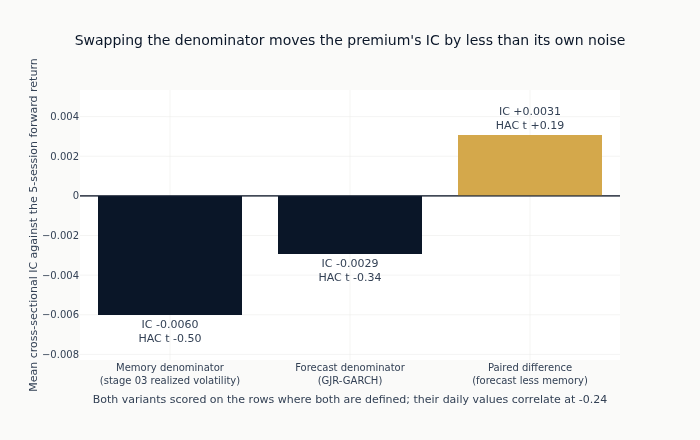

In [24]:
if COMPARABLE:
    level_colour, difference_colour = ml4t_palette(2, categorical=True)
    bars_x = [
        "Memory denominator<br>(stage 03 realized volatility)",
        "Forecast denominator<br>(GJR-GARCH)",
        "Paired difference<br>(forecast less memory)",
    ]
    bars_y = [memory_stats["mean_ic"], forecast_stats["mean_ic"], difference_stats["mean_ic"]]
    bars_t = [memory_stats["t_stat"], forecast_stats["t_stat"], difference_stats["t_stat"]]
    fig = go.Figure()
    fig.add_bar(
        x=bars_x,
        y=bars_y,
        marker_color=[level_colour, level_colour, difference_colour],
        text=[f"IC {v:+.4f}<br>HAC t {t:+.2f}" for v, t in zip(bars_y, bars_t, strict=True)],
        textposition="outside",
        cliponaxis=False,
    )
    fig.add_hline(y=0.0, line_width=1, line_color=ml4t_palette(3)[2])
    fig.update_layout(
        title="Swapping the denominator moves the premium's IC by less than its own noise",
        yaxis_title=f"Mean cross-sectional IC against the {LABEL_HORIZON}-session forward return",
        xaxis_title=(
            "Both variants scored on the rows where both are defined; their daily values "
            f"correlate at {daily_dependence:.2f}"
        ),
        margin=dict(t=90),
        height=440,
    )
    fig.show()

On the **182,379** rows where both variants are defined, across **497** decision dates, the
memory denominator gives a mean IC of **-0.0060** with a HAC t of **-0.50** and the forecast
denominator **-0.0029** with a HAC t of **-0.34**. Their daily values correlate at **-0.24**,
which is the dependence the paired test exists to handle. The paired difference is **+0.0031**
with a HAC t of **0.19**, so swapping a backward-looking denominator for a forward-looking one
is not distinguishable from making no change at all - and that now rests on a test of the
difference rather than on an inference from two tests that were about something else. Taken
standalone, none of the three features clears the false-discovery threshold either, the largest
being `garch_cond_vol` at an IC of **-0.0065** and a HAC t of **-0.34**.

## Key takeaways

- **The estimation window is part of a fitted feature's information set.** A rule computed over
  a window reads that window; a parameter estimated over a window carries every row in it into
  every value the model then produces. Fixing the window before any model runs, and asserting
  the ordering rather than describing it, is what makes the difference checkable.
- **Fixing the parameters is not the whole of fixing the fit.** A recursion also needs a value
  to start from and a range to stay inside, and a library asked to run one will derive both from
  whatever series it is given. Derive them from the estimation window explicitly, and measure
  what the convenience would have cost rather than assuming either that it is nothing or that it
  is large. C.2 is that measurement.
- **Emit the fold alongside the value.** The same date and security carry a different value per
  fold, because that is what per-fold estimation means. Writing the fold id into the key is
  what stops a consumer from joining a value to a window it did not come from.
- **Test a difference, not two levels.** Two measurements taken on the same rows are dependent,
  and neither one's standard error contains the variance of their difference. Pair them by date
  and test the paired series.
- **Report a diagnostic fold by fold when one fold is the holdout.** Reporting the coverage
  and the distributions by fold is what keeps a number read during development to the sessions
  development is allowed to see, while still emitting the feature over the holdout for the stage
  that scores it.

### Known limitations

- Only the inference-span values are point-in-time. The estimation-window values in the same
  artifact were produced under parameters estimated from that whole window, so they are
  retrospective, and they are there because a downstream model needs a feature on its training
  rows. Any diagnostic that treats them as out-of-sample is measuring the wrong thing, which is
  why section F restricts itself to the inference spans.
- The model is estimated per security and per fold with no pooling, so a security with a short
  or quiet history gets a noisier estimate than a long-established one, and one with fewer than
  the configured minimum gets no value at all. The coverage table is where that shows up.
- The parameters are held fixed across the whole span they are run over, which is the discipline
  this stage is about, and it also means the model does not adapt within a fold. A regime change
  part-way through an inference span is absorbed by the recursion's state rather than by the
  parameters.
- The conditional volatility is a one-session-ahead estimate while the implied volatility it is
  subtracted from prices the coming month. The two are in the same units and are not over the
  same horizon, so `garch_ivrv_spread` mixes horizons in a way a term-structure-aware forecast
  would not.
- A normal innovation is assumed. Equity returns have heavier tails than that, so the estimated
  persistence is likely a little high and a large move is scored as more of a surprise than a
  fatter-tailed model would score it.

**Next**: [`05_evaluation`](05_evaluation.ipynb) screens this artifact alongside stage 03's
matrix, fold by fold, and the model notebooks after it read both through
`load_modeling_dataset`.